MACHINE BREAKDOWN AND MAINTENANCE
----------------------------------
Number of Machines = 5
Machine 1: Downtime = 163.20, Production = 836.80
Machine 2: Downtime = 130.07, Production = 869.93
Machine 3: Downtime = 162.06, Production = 837.94
Machine 4: Downtime = 125.05, Production = 874.95
Machine 5: Downtime = 109.04, Production = 890.96

Overall System Downtime = 689.41
Overall System Throughput = 4310.59


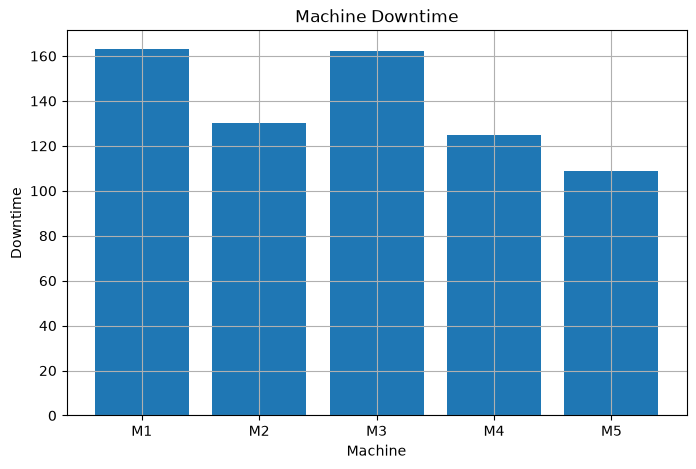

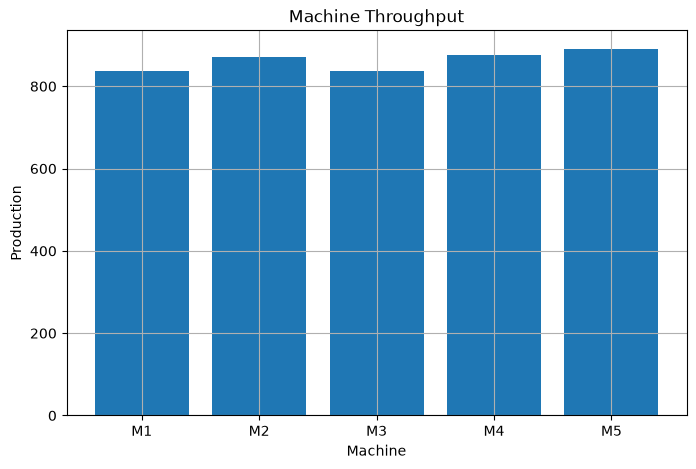

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

NUM_MACHINES = 5
SIM_TIME = 1000

# Exponential Breakdown
MEAN_TIME_BETWEEN_FAILURES = 50

# Weibull Repair
WEIBULL_SHAPE = 2.0
WEIBULL_SCALE = 10

# Production Rate
PRODUCTION_RATE = 1

# ---------------------------------
# Variables
# ---------------------------------

total_downtime = np.zeros(NUM_MACHINES)
total_production = np.zeros(NUM_MACHINES)

# ---------------------------------
# Simulation
# ---------------------------------

for machine in range(NUM_MACHINES):

    current_time = 0

    while current_time < SIM_TIME:

        # Time until breakdown
        working_time = np.random.exponential(
            MEAN_TIME_BETWEEN_FAILURES
        )

        if current_time + working_time > SIM_TIME:
            total_production[machine] += (
                SIM_TIME - current_time
            ) * PRODUCTION_RATE
            break

        # Machine produces while working
        total_production[machine] += (
            working_time * PRODUCTION_RATE
        )

        current_time += working_time

        # Repair time (Weibull)
        repair_time = (
            np.random.weibull(WEIBULL_SHAPE)
            * WEIBULL_SCALE
        )

        total_downtime[machine] += repair_time

        current_time += repair_time

# ---------------------------------
# Results
# ---------------------------------

system_downtime = np.sum(total_downtime)
system_throughput = np.sum(total_production)

print("MACHINE BREAKDOWN AND MAINTENANCE")
print("----------------------------------")
print("Number of Machines =", NUM_MACHINES)

for i in range(NUM_MACHINES):
    print(
        f"Machine {i+1}: "
        f"Downtime = {total_downtime[i]:.2f}, "
        f"Production = {total_production[i]:.2f}"
    )

print("\nOverall System Downtime =",
      round(system_downtime, 2))

print("Overall System Throughput =",
      round(system_throughput, 2))

# ---------------------------------
# Visualization
# ---------------------------------

machines = [
    f"M{i+1}" for i in range(NUM_MACHINES)
]

plt.figure(figsize=(8,5))
plt.bar(machines, total_downtime)

plt.xlabel("Machine")
plt.ylabel("Downtime")
plt.title("Machine Downtime")
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))
plt.bar(machines, total_production)

plt.xlabel("Machine")
plt.ylabel("Production")
plt.title("Machine Throughput")
plt.grid(True)

plt.show()